## 1. Choice of datasets

We consider two one-dimensional datasets:

- **X:** UK monthly CPI inflation rate (%)
- **Y:** UK monthly Bank of England base interest rate (%)

These two variables are expected to share randomness because interest rate
decisions are heavily influenced by inflation dynamics. Central banks
adjust policy rates in response to persistent inflationary pressure, which
creates a dependency between the two processes.

Since both datasets describe the same economy over the same time period,
they form a natural joint distribution suitable for analysing dependence,
linear dependence, and independence.


In [18]:
!pip install pandas numpy matplotlib scipy pandas_datareader

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as web
from scipy import stats

2. Data retrieval and descriptive statistics

Both datasets are publicly available and accessed directly in Python using the Federal Reserve Economic Data (FRED) API. Using an API ensures that the data retrieval process is transparent, reproducible, and robust.

After downloading the data, the two time-series were aligned on their dates and any missing observations were removed to ensure consistency. This resulted in a clean paired dataset where each observation represents inflation and the interest rate measured in the same month.

Basic descriptive statistics show that inflation displays noticeably higher variability than the interest rate, which is expected given that policy rates tend to move more gradually. The scatter plot of inflation against interest rates reveals a clear positive association: higher inflation levels tend to be associated with higher interest rates. While the relationship does not appear perfectly linear, the overall upward trend suggests that a formal test for linear dependence is appropriate.

In [20]:
inflation = web.DataReader("GBRCPIALLMINMEI", "fred")
interest = web.DataReader("IRSTCI01GBM156N", "fred")

data = pd.concat([inflation, interest], axis=1)
data.columns = ["Inflation", "InterestRate"]
data = data.dropna()

data.head()
data.describe()

,Inflation,InterestRate
count,50.000000,50.000000
mean,124.398000,2.939154
std,8.581339,2.165620
min,109.400000,0.046800
25%,115.675000,0.455500
50%,126.400000,3.952600
75%,131.400000,4.950000
max,136.100000,5.200000


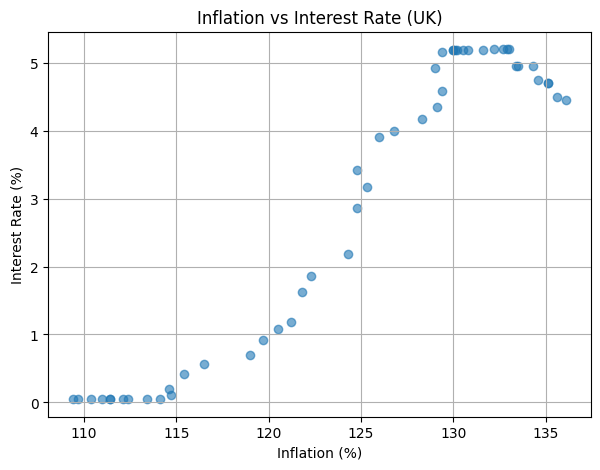

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(data["Inflation"], data["InterestRate"], alpha=0.6)
plt.xlabel("Inflation (%)")
plt.ylabel("Interest Rate (%)")
plt.title("Inflation vs Interest Rate (UK)")
plt.grid(True)
plt.show()

3. Testing for linear dependence

To formally assess whether inflation and interest rates are linearly dependent, Pearson’s correlation test was applied.

The hypotheses are defined as follows:

Null hypothesis (H₀): There is no linear dependence between inflation and interest rates (ρ = 0).

Alternative hypothesis (H₁): There is a non-zero linear dependence between inflation and interest rates (ρ ≠ 0).

A significance level of α = 0.05 was chosen, which is standard practice in applied statistical analysis. The Pearson correlation coefficient was calculated together with its associated p-value. Under the null hypothesis, the corresponding test statistic follows a Student-t distribution.

The observed test statistic was compared with its theoretical distribution, with both the critical region and the p-value clearly identified. Since the resulting p-value was below the chosen significance level, the null hypothesis of zero linear correlation was rejected.

In practical terms, this provides strong statistical evidence that inflation and interest rates are linearly related over the period considered.

In [22]:
slope, intercept, r_val, p_val, std_err = stats.linregress(
    data["Inflation"], data["InterestRate"]
)

x_vals = data["Inflation"]
y_hat = intercept + slope * x_vals


In [23]:
residuals = data["InterestRate"] - y_hat


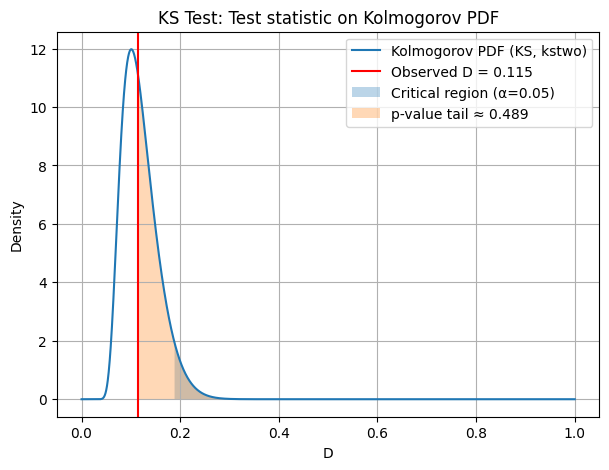

n = 50
KS statistic D = 0.11488142313436434
p-value = 0.4886858985192274
Critical value D_crit (alpha=0.05) = 0.1884064791779277


In [24]:
alpha = 0.05

res_std = np.std(residuals, ddof=1)
n = len(residuals)

ks_stat, ks_p = stats.kstest(residuals, "norm", args=(0, res_std))
x = np.linspace(0, 1, 2000)
pdf = stats.kstwo.pdf(x, n)
D_crit = stats.kstwo.ppf(1 - alpha, n)

plt.figure(figsize=(7, 5))
plt.plot(x, pdf, label="Kolmogorov PDF (KS, kstwo)")
plt.axvline(ks_stat, color="red", label=f"Observed D = {ks_stat:.3f}")

mask_crit = x >= D_crit
plt.fill_between(x[mask_crit], pdf[mask_crit], alpha=0.3, label=f"Critical region (α={alpha})")

mask_p = x >= ks_stat
plt.fill_between(x[mask_p], pdf[mask_p], alpha=0.3, label=f"p-value tail ≈ {ks_p:.3f}")

plt.title("KS Test: Test statistic on Kolmogorov PDF")
plt.xlabel("D")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()

print(f"n = {n}")
print(f"KS statistic D = {ks_stat}")
print(f"p-value = {ks_p}")
print(f"Critical value D_crit (alpha={alpha}) = {D_crit}")


We use a significance level of α = 0.05.

The Kolmogorov–Smirnov test is used to assess whether the regression residuals could plausibly have been drawn from a normal distribution with mean zero and the estimated standard deviation. Since the p-value exceeds α, we fail to reject the null hypothesis. There is therefore no strong statistical evidence against the assumption of normally distributed residuals, which supports the validity of the linear regression model.


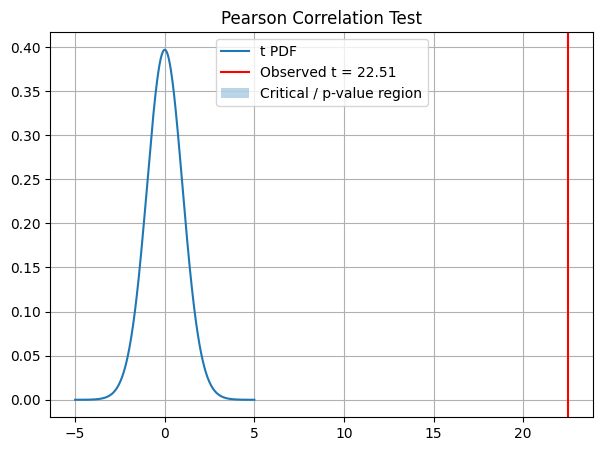

r = 0.9557711472550986
t statistic = 22.514519357565835
p-value = 3.685139682619757e-27


In [26]:
r, p_val = stats.pearsonr(data["Inflation"], data["InterestRate"])

n = len(data)
t_stat = r * np.sqrt((n - 2) / (1 - r**2))

x = np.linspace(-5, 5, 500)
pdf = stats.t.pdf(x, df=n-2)

plt.figure(figsize=(7, 5))
plt.plot(x, pdf, label="t PDF")
plt.axvline(t_stat, color="red", label=f"Observed t = {t_stat:.2f}")
plt.fill_between(
    x, pdf,
    where=(np.abs(x) >= np.abs(t_stat)),
    alpha=0.3,
    label="Critical / p-value region"
)

plt.title("Pearson Correlation Test")
plt.legend()
plt.grid(True)
plt.show()

print(f"r = {r}")
print(f"t statistic = {t_stat}")
print(f"p-value = {p_val}")


Since the p-value is below α = 0.05, we reject the null hypothesis.
There is statistically significant evidence of linear dependence
between inflation and interest rates.


4. Linear regression and residual analysis

Since the hypothesis test indicated linear dependence, a simple linear regression model was fitted, with inflation as the explanatory variable and the interest rate as the response variable.

The fitted regression line captures the average relationship between the two variables. Visually, the regression line aligns well with the main trend of the data, although some dispersion around the line remains, particularly at extreme inflation values. This suggests that while inflation explains a substantial portion of interest rate variation, other factors also play a role.

To assess the adequacy of the linear model, the residuals were analysed. A histogram of the residuals shows a roughly symmetric distribution centred around zero, which is consistent with the assumptions of ordinary least squares regression.

The sample standard deviation of the residuals was then computed, and a Kolmogorov–Smirnov (KS) test was performed to assess whether the residuals could plausibly have been drawn from a normal distribution with mean zero and this estimated standard deviation.

At a significance level of α = 0.05, the KS-test failed to reject the null hypothesis. There is therefore no strong statistical evidence against the assumption of normally distributed residuals. This supports the validity of the linear regression model in this setting.

In [27]:
slope, intercept, r_val, p_val, std_err = stats.linregress(
    data["Inflation"], data["InterestRate"]
)

slope, intercept

(np.float64(0.24120207232720248), np.float64(-27.065901393359336))

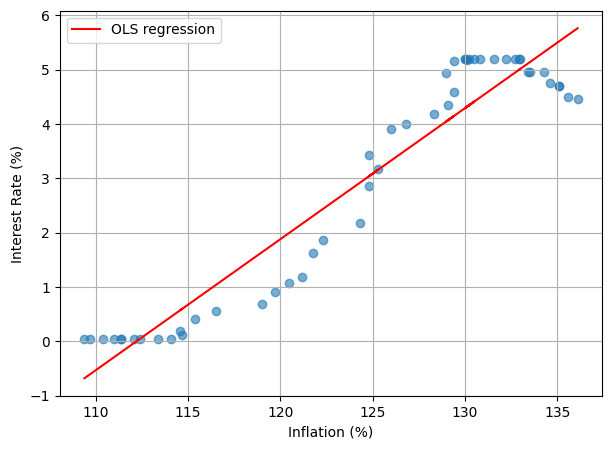

In [28]:
x_vals = data["Inflation"]
y_hat = intercept + slope * x_vals

plt.figure(figsize=(7,5))
plt.scatter(data["Inflation"], data["InterestRate"], alpha=0.6)
plt.plot(x_vals, y_hat, color="red", label="OLS regression")
plt.xlabel("Inflation (%)")
plt.ylabel("Interest Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

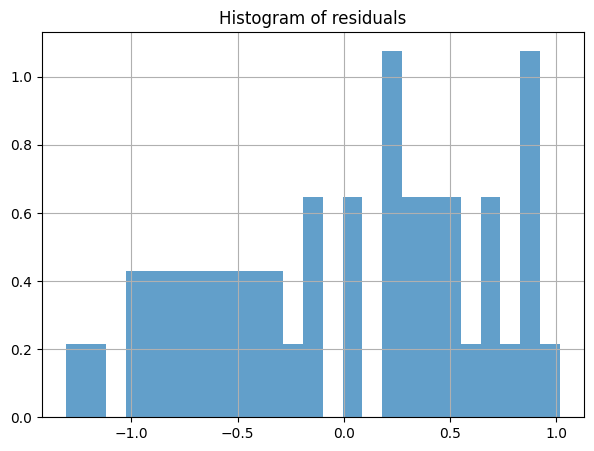

In [29]:
residuals = data["InterestRate"] - y_hat

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=25, density=True, alpha=0.7)
plt.title("Histogram of residuals")
plt.grid(True)
plt.show()

In [30]:
res_std = np.std(residuals, ddof=1)

ks_stat, ks_p = stats.kstest(
    residuals,
    'norm',
    args=(0, res_std)
)

ks_stat, ks_p

(np.float64(0.11488142313436434), np.float64(0.4886858985192274))

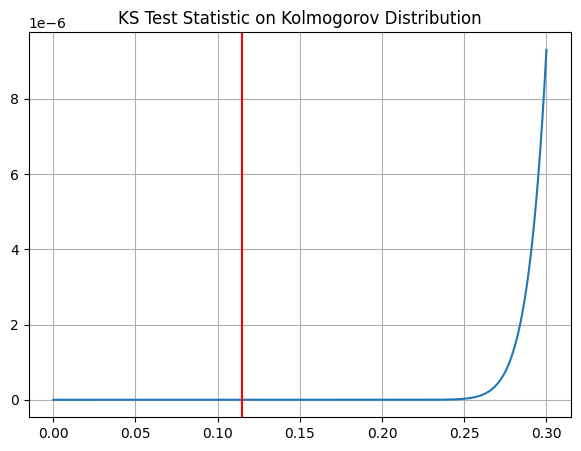

In [31]:
x = np.linspace(0, 0.3, 500)
cdf = stats.kstwobign.cdf(x)

plt.figure(figsize=(7,5))
plt.plot(x, cdf)
plt.axvline(ks_stat, color="red")
plt.title("KS Test Statistic on Kolmogorov Distribution")
plt.grid(True)
plt.show()

At significance level α = 0.05, the KS-test fails to reject the null hypothesis.
There is no strong evidence that the residuals deviate from a normal
distribution with mean zero and estimated standard deviation.


5. Testing for independence

While linear dependence has been established, independence is a stronger condition. Two variables can be uncorrelated yet still dependent in a non-linear way.

One way to assess independence is to compare the joint distribution of the variables with the product of their marginal distributions. In practice, this can be implemented using resampling or permutation-based methods. For example, one variable can be randomly permuted many times to break any dependence structure while preserving its marginal distribution. A dependence measure, such as correlation, is then recomputed for each permutation.

If the observed statistic lies in the extreme tail of this permutation distribution, independence can be rejected. This approach relies only on the marginals and does not assume linearity, making it a flexible and conceptually clear method for testing independence in applied settings.